In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rv_continuous
from scipy import integrate

In [19]:
class CustomDistribution(rv_continuous):
 
    def __init__(self, a, b):
        super().__init__(a=a, b=b, name='sine_dist')
    
    def _pdf(self, x):
        """Плотность распределения: φ(x) = sin(x)/2"""
        result = np.zeros_like(x, dtype=float)
        result[(x >= self.a) & (x <= self.b)] = np.sin(x) / 2
        return result
    
    def _cdf(self, x):
        """
        Функция распределения: F(x) = (1 - cos(x))/2
        """
        result = np.zeros_like(x)
        result[x < self.a] = 0
        result[(x >= self.a) & (x <= self.b)] = (1 - np.cos(x)) / 2
        result[x > self.b] = 1
        return result

In [23]:
# Создание экземпляра распределения
a, b = 0.0, np.pi
custom_dist = CustomDistribution(a, b)

print("="*60)
print("АНАЛИЗ СОБСТВЕННОГО РАСПРЕДЕЛЕНИЯ")
print("Плотность: φ(x) = sin(x)/2 на интервале [0, π]")
print("="*60)

# Генерация выборки
np.random.seed(42)
sample = custom_dist.rvs(size=10000)

print(f"\nРазмер выборки: {len(sample)}")
print(f"Первые 10 значений: {sample[:10]}")

АНАЛИЗ СОБСТВЕННОГО РАСПРЕДЕЛЕНИЯ
Плотность: φ(x) = sin(x)/2 на интервале [0, π]

Размер выборки: 10000
Первые 10 значений: [1.3172 2.6939 2.0533 1.7694 0.8121 0.8121 0.4868 2.3926 1.7744 2.0000]


# 1. Проверка условия нормировки

In [28]:
integral, error = integrate.quad(custom_dist.pdf, a, b)
print(f"∫f(x)dx на [{a:.4f}, {b:.4f}] = {integral:.10f}")
print(f"Ошибка интегрирования: {error:.2e}")

if abs(integral - 1.0) < 1e-6:
    print("✓ Условие нормировки выполнено: ∫f(x)dx = 1")
else:
    print("✗ Условие нормировки НЕ выполнено!")

print("\nПроверка в граничных точках:")
print(f"F({a:.4f}) = {custom_dist.cdf(a):.10f} (должно быть 0)")
print(f"F({b:.4f}) = {custom_dist.cdf(b):.10f} (должно быть 1)")



∫f(x)dx на [0.0000, 3.1416] = 1.0000000000
Ошибка интегрирования: 1.11e-14
✓ Условие нормировки выполнено: ∫f(x)dx = 1

Проверка в граничных точках:
F(0.0000) = 0.0000000000 (должно быть 0)
F(3.1416) = 1.0000000000 (должно быть 1)


# 2. Построение графиков

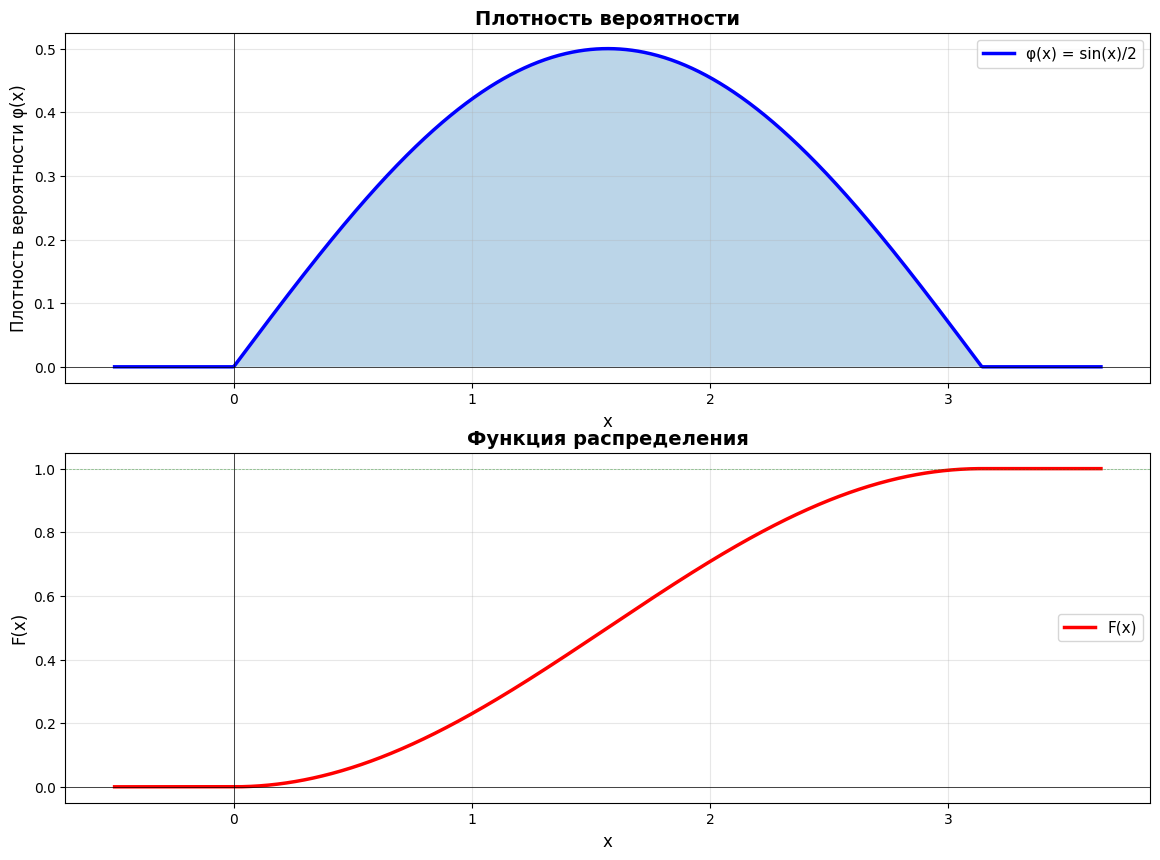

In [51]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(14, 10))
x_plot = np.linspace(a - 0.5, b + 0.5, 1000)

# График 1: Плотность вероятности
ax1.plot(x_plot, custom_dist.pdf(x_plot), 'b-', linewidth=2.5, label='φ(x) = sin(x)/2')
ax1.fill_between(x_plot, 0, custom_dist.pdf(x_plot), alpha=0.3)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('Плотность вероятности φ(x)', fontsize=12)
ax1.set_title('Плотность вероятности', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)

# График 2: Функция распределения
ax2.plot(x_plot, custom_dist.cdf(x_plot), 'r-', linewidth=2.5, label='F(x)')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('F(x)', fontsize=12)
ax2.set_title('Функция распределения', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axhline(y=1, color='g', linewidth=0.5, linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)

# 3. Вероятность попадания в интервал

In [55]:
intervals = [
    (0.5, 1.5),
    (1.0, 2.0),
    (np.pi/4, 3*np.pi/4)
]

for x1, x2 in intervals:
    prob = custom_dist.cdf(x2) - custom_dist.cdf(x1)
    print(f"P({x1:.4f} ≤ X ≤ {x2:.4f}) = {prob:.6f}")

P(0.5000 ≤ X ≤ 1.5000) = 0.403423
P(1.0000 ≤ X ≤ 2.0000) = 0.478225
P(0.7854 ≤ X ≤ 2.3562) = 0.707107


# 4. Вычисление числовых характеристик

In [59]:
mean = custom_dist.mean()
variance = custom_dist.var()
std = custom_dist.std()

print(f"Математическое ожидание E[X]: {mean:.6f}")
print(f"Дисперсия D[X]: {variance:.6f}")
print(f"Среднее квадратическое отклонение σ: {std:.6f}")

Математическое ожидание E[X]: 1.570796
Дисперсия D[X]: 0.467401
Среднее квадратическое отклонение σ: 0.683667


# 5. Вычисление квантилей

In [71]:
quantile_levels = [0.25, 0.5, 0.75, 0.9]
for q in quantile_levels:
    quantile_value = custom_dist.ppf(q)
    print(f"{q}-квантиль (x_{q}): {quantile_value:.6f}")

print("\nПроцентные точки:")
percentiles = [10, 20, 80, 95]
for p in percentiles:
    percentile_value = custom_dist.ppf(1 - p/100)
    print(f"{p}%-ная точка: {percentile_value:.6f}")

0.25-квантиль (x_0.25): 1.047198
0.5-квантиль (x_0.5): 1.570796
0.75-квантиль (x_0.75): 2.094395
0.9-квантиль (x_0.9): 2.498092

Процентные точки:
10%-ная точка: 2.498092
20%-ная точка: 2.214297
80%-ная точка: 0.927295
95%-ная точка: 0.451027


# 6. Коэффициент асимметрии и эксцесс

In [80]:
mean_stat, var_stat, skew, kurt = custom_dist.stats(moments='mvsk')

print(f"Коэффициент асимметрии: {skew:.6f}")
print(f"Эксцесс: {kurt:.6f}")

Коэффициент асимметрии: -0.000000
Эксцесс: -0.806250
